In [1]:
# from turtle import pos

import matplotlib

# matplotlib.use("Agg")  # for mac users

#print(matplotlib.get_backend())

import sys

import matplotlib as mpl

sys.path.append("/home/weipeng/CODES/Smilei")
import happi
import matplotlib.pyplot as plt
import numpy as np

jetcmap = plt.cm.get_cmap(
    "jet", 9
)  # generate a jet map with 10 values "rainbow", "jet", YlOrRd
jet_vals = jetcmap(np.arange(9))  # extract those values as an array
jet_vals[0] = [1.0, 1, 1.0, 1]  # change the first value
jet_vals[8] = [0.0, 0, 0.0, 1]  # change the first value
newcmap = mpl.colors.LinearSegmentedColormap.from_list("mine", jet_vals)

from matplotlib import font_manager

font_dirs = ["/Users/yao/Documents/Calibri and Cambria Fonts/"]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
   font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams["font.family"] = "Calibri"

plt.rc("text", usetex=False)
plt.rc("xtick", labelsize=14)
plt.rc("ytick", labelsize=14)
plt.rc("axes", labelsize=14)
plt.rc("legend", fontsize=12)

import scienceplots as splt

plt.style.use(["nature", "notebook", "grid", "high-vis"])

/var/folders/2t/97rc3fl92tg15k2l_4sk5hsh0000gn/T/ipykernel_13683/4764761.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  jetcmap = plt.cm.get_cmap(


In [6]:
wkdir = [
    # "/scratch/weipeng/Data_smilei/2025/ife_uhi/ife_001/", #a0=500
    # "/scratch/weipeng/Data_smilei/2025/ife_uhi/ife_002/", #a0=600
    # "/scratch/weipeng/Data_smilei/2025/ife_uhi/ife_003/", #a0=400
    # "/scratch/weipeng/Data_smilei/2025/ife_uhi/ife_004/", #a0=300
    "/Users/yao/Documents/Data/IFE/ife_005/", #a0=700
    "/Users/yao/Documents/Data/IFE/ife_001_ne60/", #a0=500
    "/Users/yao/Documents/Data/IFE/ife_002_ne60/", #a0=600
    # "/Volumes/Irene/IFE2026_Rome/ife05_ppc1/", # a0=700
    # "/Volumes/Irene/IFE2026_Rome/ife06_ppc1/", # a0=200
]

S0 = happi.Open(
    wkdir[0], reference_angular_frequency_SI=2.0 * np.pi * 3e8 / (1.0 * 1e-6)
)
S1 = happi.Open(
    wkdir[1], reference_angular_frequency_SI=2.0 * np.pi * 3e8 / (1.0 * 1e-6)
)
S2 = happi.Open(
    wkdir[2], reference_angular_frequency_SI=2.0 * np.pi * 3e8 / (1.0 * 1e-6)
)
# S3 = happi.Open(
#     wkdir[3], reference_angular_frequency_SI=2.0 * np.pi * 3e8 / (1.0 * 1e-6)
# )
# S4 = happi.Open(
#     wkdir[4], reference_angular_frequency_SI=2.0 * np.pi * 3e8 / (1.0 * 1e-6)
# )
# S5 = happi.Open(
#     wkdir[5], reference_angular_frequency_SI=2.0 * np.pi * 3e8 / (1.0 * 1e-6)
# )
# S6 = happi.Open(
#     wkdir[6], reference_angular_frequency_SI=2.0 * np.pi * 3e8 / (1.0 * 1e-6)
# )
# S7 = happi.Open(
#     wkdir[7], reference_angular_frequency_SI=2.0 * np.pi * 3e8 / (1.0 * 1e-6)
# )
# S8 = happi.Open(
#     wkdir[8], reference_angular_frequency_SI=2.0 * np.pi * 3e8 / (1.0 * 1e-6)
# )

# Get simulation box size
Lx = S0.namelist.Lx / 2 / np.pi  # in um
print("Lx = ", Lx)
Ly = S0.namelist.Ly / 2 / np.pi  # in um
print("Ly = ", Ly)
Lz = S0.namelist.Lz / 2 / np.pi  # in um
print("Lz = ", Lz)

Loaded simulation '/Users/yao/Documents/Data/IFE/ife_005/'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning for ParticleBinning diagnostics
Scanning for RadiationSpectrum diagnostics
Scanning for Performance diagnostics
Scanning for Screen diagnostics
Scanning for Tracked particle diagnostics
Scanning for new particle diagnostics
Loaded simulation '/Users/yao/Documents/Data/IFE/ife_001_ne60/'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning for ParticleBinning diagnostics
Scanning for RadiationSpectrum diagnostics
Scanning for Performance diagnostics
Scanning for Screen diagnostics
Scanning for Tracked particle diagnostics
Scanning for new particle diagnostics
Loaded simulation '/Users/yao/Documents/Data/IFE/ife_002_ne60/'
Scanning for Scalar diagnostics
Scanning for Field diagnostics
Scanning for Probe diagnostics
Scanning for ParticleBinning diagnostics
Scanning for RadiationSp

In [7]:
def get_fft(S, time, vmin0, vmax0):
    Bx = S.Probe(0, "Bx", units=["um", "fs", "1e5 T"])
    data = np.array(Bx.getData()[time])
    field_x = np.array(Bx.getAxis("axis1"))
    field_y = np.array(Bx.getAxis("axis2"))
    print("time = ", Bx.getTimes()[time], " fs")

    plt.figure(figsize=(6, 5))
    plt.imshow(
        data.T,
        extent=(field_x.min(), field_x.max(), field_y.min(), field_y.max()),
        origin="lower",
        cmap="bwr",
        aspect="auto",
        vmin=vmin0,
        vmax=vmax0,
    )
    plt.colorbar()
    plt.xlabel("x (um)")
    plt.ylabel("y (um)")
    plt.title("Bx field in real space (before FFT)")
    plt.tight_layout()
    plt.savefig("data_before_FFT.png", dpi=300)
    # plt.show()

    Nx = data.shape[0]
    Ny = data.shape[1]
    dx = (field_x[1] - field_x[0])[0]
    dy = (field_y[1] - field_y[0])[1]
    kx = np.fft.fftfreq(Nx, d=dx)  # / (2 * np.pi)  # spatial freq extents
    ky = np.fft.fftfreq(Ny, d=dy)  # / (2 * np.pi)
    KX, KY = np.meshgrid(kx, ky, indexing="ij")

    data_fft = np.fft.fft2(data, axes=(0, 1))  # shape (Nx, Ny)

    # plt.figure(figsize=(6, 5))
    # plt.imshow(
    #     np.log10(np.abs(data_fft).T),
    #     extent=(kx.min(), kx.max(), ky.min(), ky.max()),
    #     origin="lower",
    # )
    # plt.colorbar()
    # plt.xlabel("kx (1/um)")
    # plt.ylabel("ky (1/um)")
    # plt.title("Fourier Transform of Bx in log10 scale")
    # plt.tight_layout()
    # plt.show()

    data_fft_shift = np.fft.fftshift(data_fft)
    kx_shift = np.fft.fftshift(kx)
    ky_shift = np.fft.fftshift(ky)

    plt.figure(figsize=(6, 5))
    plt.imshow(
        np.log10(np.abs(data_fft_shift).T),
        extent=(kx_shift.min(), kx_shift.max(), ky_shift.min(), ky_shift.max()),
        origin="lower",
    )
    plt.colorbar()
    plt.xlabel("kx (1/um)")
    plt.ylabel("ky (1/um)")
    plt.title("Shifted (& Zoom) Fourier Transform of Bx in log10 scale")
    plt.xlim(-2, 2)
    plt.ylim(-2, 2)
    plt.tight_layout()
    plt.savefig("FFT_shift_zoom.png", dpi=300)
    # plt.show(block=True)

    print(
        "With these plots, you can identify the dominant spatial frequencies in the Bx field."
    )
    print(
        "You can now design your mask to filter out unwanted frequencies accordingly."
    )

    return data, data_fft, kx, ky, KX, KY, field_x, field_y


def apply_mask_and_ifft(data_fft, kx, ky, KX, KY, k0x, k0y, wx, wy):
    pwr = 12  # super gaussian power

    # # adjust the mask parameters here according to the FFT plot
    # k0x = 0.4
    # k0y = 0.4
    # wx = 0.3
    # wy = 0.4

    mask = 1 - np.exp(
        -(
            np.sqrt(((np.abs(KX) - k0x) / wx) ** 2 + ((np.abs(KY) - k0y) / wy) ** 2)
            ** pwr
        )
    )
    # a quick check of the mask
    # plt.figure(figsize=(6, 5))
    # plt.imshow(mask.T, extent=(kx.min(), kx.max(), ky.min(), ky.max()), origin="lower")
    # plt.colorbar()
    # plt.xlabel("kx (1/um)")
    # plt.ylabel("ky (1/um)")
    # plt.title("Fourier Mask")
    # plt.tight_layout()
    # plt.show()

    mask_shift = np.fft.fftshift(mask)

    # plt.figure(figsize=(6, 5))
    # plt.imshow(
    #     mask_shift.T, extent=(kx.min(), kx.max(), ky.min(), ky.max()), origin="lower"
    # )
    # plt.colorbar()
    # plt.xlabel("kx (1/um)")
    # plt.ylabel("ky (1/um)")
    # plt.title("Shifted & Zoomed Fourier Mask")
    # plt.xlim(-2, 2)
    # plt.ylim(-2, 2)
    # plt.tight_layout()
    # plt.show()

    data_fft_masked = data_fft * mask
    data_fft_masked_shift = np.fft.fftshift(data_fft_masked)

    plt.figure(figsize=(6, 5))
    plt.imshow(
        np.log10(np.abs(data_fft_masked_shift).T),
        extent=(kx.min(), kx.max(), ky.min(), ky.max()),
        origin="lower",
    )
    plt.colorbar()
    plt.xlabel("kx (1/um)")
    plt.ylabel("ky (1/um)")
    plt.title("Masked & Shifted Fourier Transform of Bx in log10 scale")
    plt.xlim(-2, 2)
    plt.ylim(-2, 2)
    plt.tight_layout()
    plt.savefig("FFT_masked_shift_zoom.png", dpi=300)
    # plt.show(block=True)

    return data_fft_masked


def compute_ifft(data_fft_masked, field_x, field_y, vmin0, vmax0):
    data_ifft = np.real(np.fft.ifft2(data_fft_masked))

    plt.figure(figsize=(6, 5))
    plt.imshow(
        data_ifft.T,
        extent=(field_x.min(), field_x.max(), field_y.min(), field_y.max()),
        origin="lower",
        cmap="bwr",
        aspect="auto",
        vmin=vmin0,
        vmax=vmax0,
    )
    plt.colorbar()
    plt.xlabel("x (um)")
    plt.ylabel("y (um)")
    plt.title("Filtered Bx field in real space (after IFFT)")
    plt.tight_layout()
    plt.savefig("data_after_FFT.png", dpi=300)
    # plt.show(block=True)

    return data_ifft


def plot_comparison(Bx_original, Bx_filtered):
    Nx = Bx_original.shape[0]
    Ny = Bx_original.shape[1]
    xx = np.linspace(0, Lx, Bx_original.shape[0])
    yy = np.linspace(0, Ly, Bx_original.shape[1])

    plt.figure(figsize=(6, 5))
    plt.plot(xx, Bx_original[:, Ny // 2], label="Original Bx")
    plt.plot(xx, Bx_filtered[:, Ny // 2], label="Filtered Bx")
    plt.xlabel("x (um)")
    plt.ylabel("Bx (1e5 T)")
    plt.title("Lineout of Bx at y=0")
    plt.xlim(0, Lx)
    plt.legend()
    plt.tight_layout()
    plt.savefig("data_lineout.png", dpi=300)
    # plt.show(block=True)
    #
    pos = 200
    print(xx[pos])
    #
    print("max Bx_ori = ", np.max(np.abs(Bx_original[pos:, Ny // 2])), " GG")
    print("max Bx_filt = ", np.max(np.abs(Bx_filtered[pos:, Ny // 2])), " GG")
    print(
        "error bar = ",
        (np.max(np.abs(Bx_original[pos:, Ny // 2]))
        - np.max(np.abs(Bx_filtered[pos:, Ny // 2])))/2.,
        " GG",
    )
    print("ave Bx = ", np.max(np.abs(Bx_original[pos:, Ny // 2])) - ((np.max(np.abs(Bx_original[pos:, Ny // 2]))
        - np.max(np.abs(Bx_filtered[pos:, Ny // 2])))/2.), " GG")

    cell_y = 12  # 1 cell = 0.04 um along y
    center = int(Bx_original.shape[1] / 2)

    plt.figure(figsize=(6, 5))
    plt.plot(
        xx,
        np.average(Bx_original[:, (center - cell_y) : (center + cell_y)], axis=1),
        label="Original Bx",
        color="blue",
        linestyle="-",
    )
    plt.plot(
        xx,
        np.average(Bx_filtered[:, (center - cell_y) : (center + cell_y)], axis=1),
        label="Filtered Bx",
        color="red",
        linestyle="--",
    )
    plt.xlabel("x (um)")
    plt.ylabel("Bx (1e5 T)")
    plt.title(
        "Averaged Bx field at y = {:.1f} um with a width of {:.1f} um".format(
            yy[center], 2 * cell_y * (Ly / Bx_original.shape[1])
        )
    )
    plt.legend()
    plt.xlim(0, Lx)
    plt.tight_layout()
    plt.savefig("data_lineout_averaged.png", dpi=300)
    # plt.show(block=True)


def post_process_Bx_field(S, k0x, k0y, wx, wy, timestep, vmin0, vmax0):
    Bx0, Bx0_fft, kx0, ky0, KX0, KY0, field_x0, field_y0 = get_fft(
        S, timestep, vmin0, vmax0
    )
    Bx0_fft_masked = apply_mask_and_ifft(Bx0_fft, kx0, ky0, KX0, KY0, k0x, k0y, wx, wy)
    Bx0_ifft = compute_ifft(Bx0_fft_masked, field_x0, field_y0, vmin0, vmax0)
    plot_comparison(Bx0, Bx0_ifft)

In [4]:
S0.Probe(0,'Bx').getAvailableTimesteps()

array([   0.,  729., 1458., 2187., 2916., 3645., 4374., 5103., 5832.,
       6561., 7290., 8019., 8748., 9477.])

time =  133.28130964242507  fs
With these plots, you can identify the dominant spatial frequencies in the Bx field.
You can now design your mask to filter out unwanted frequencies accordingly.


/var/folders/2t/97rc3fl92tg15k2l_4sk5hsh0000gn/T/ipykernel_13683/464827179.py:124: RuntimeWarning: divide by zero encountered in log10
  np.log10(np.abs(data_fft_masked_shift).T),


6.406406406406406
max Bx_ori =  3.2001074620080634  GG
max Bx_filt =  2.633278307114395  GG
error bar =  0.2834145774468342  GG
ave Bx =  2.916692884561229  GG


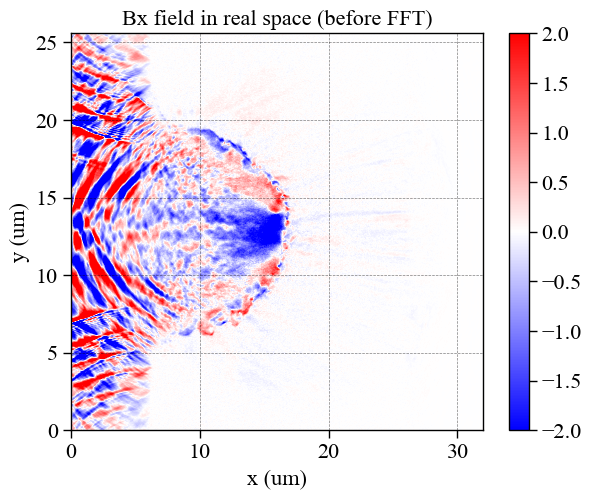

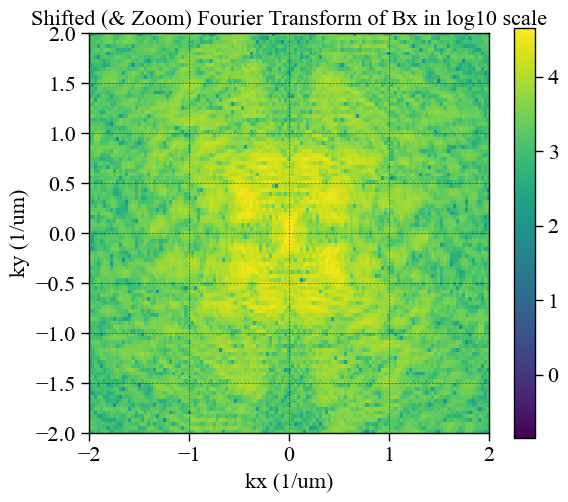

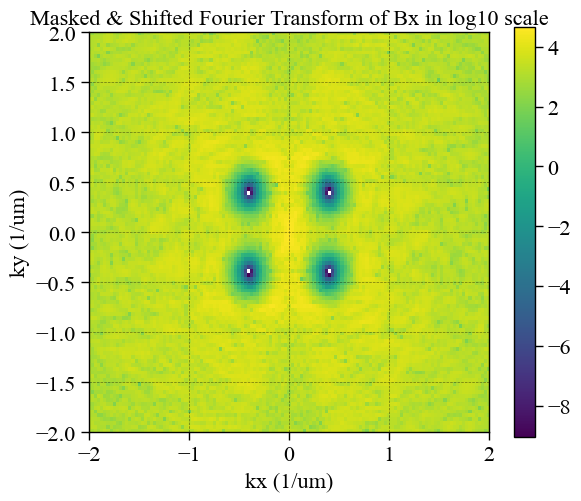

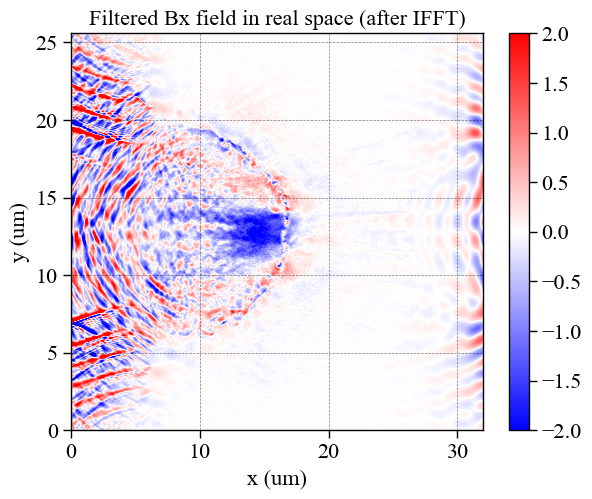

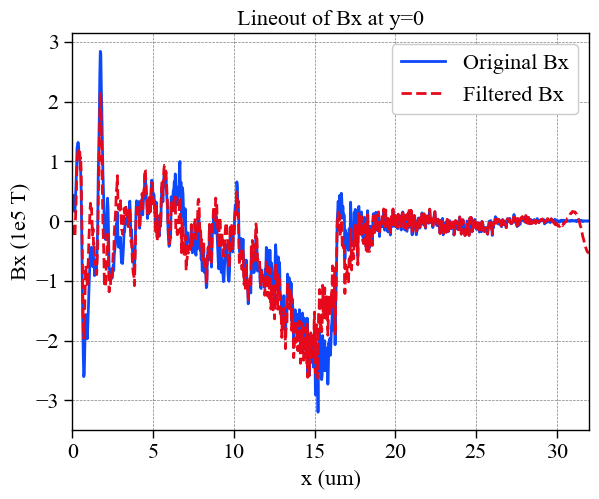

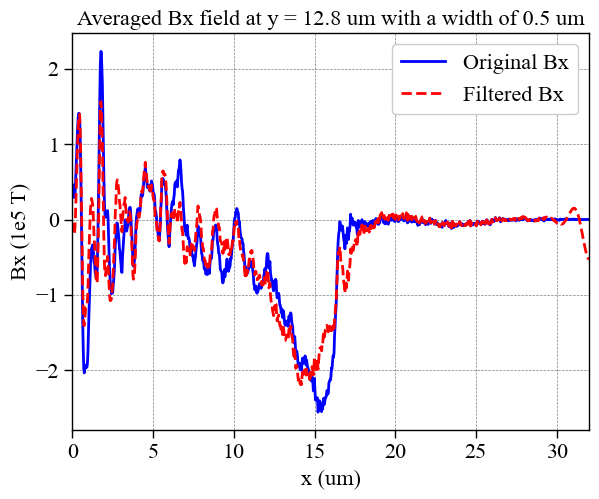

In [5]:
post_process_Bx_field(
    S0, k0x=0.4, k0y=0.4, wx=0.3, wy=0.4, timestep=8, vmin0=-2, vmax0=2
)

time =  149.9414733477282  fs
With these plots, you can identify the dominant spatial frequencies in the Bx field.
You can now design your mask to filter out unwanted frequencies accordingly.


/var/folders/2t/97rc3fl92tg15k2l_4sk5hsh0000gn/T/ipykernel_13683/464827179.py:124: RuntimeWarning: divide by zero encountered in log10
  np.log10(np.abs(data_fft_masked_shift).T),


6.406406406406406
max Bx_ori =  2.1329064779944598  GG
max Bx_filt =  2.1818790754277297  GG
error bar =  -0.02448629871663499  GG
ave Bx =  2.1573927767110948  GG


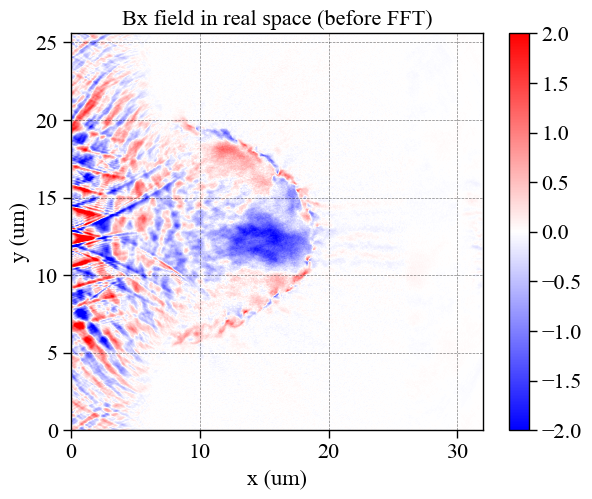

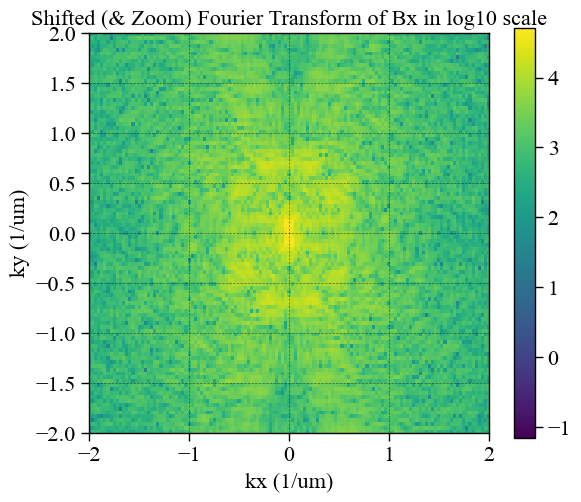

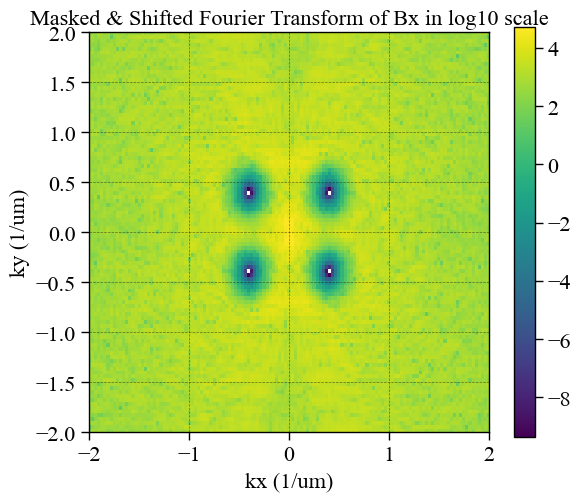

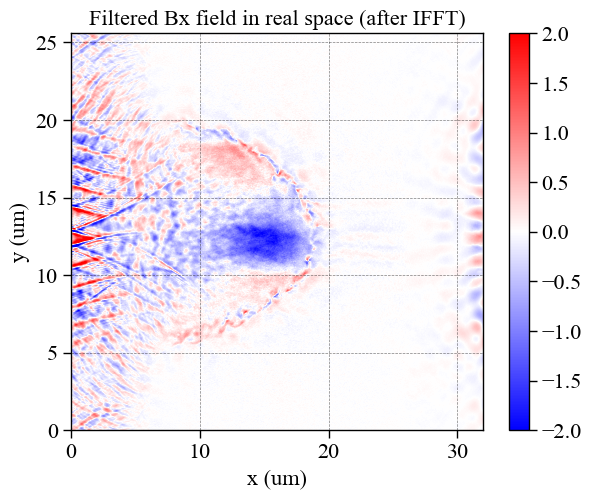

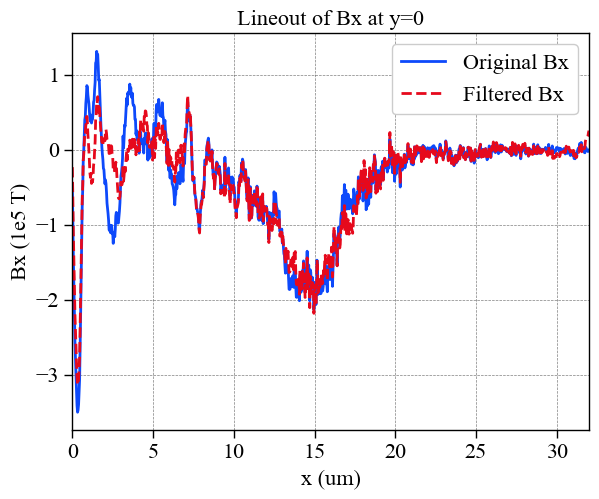

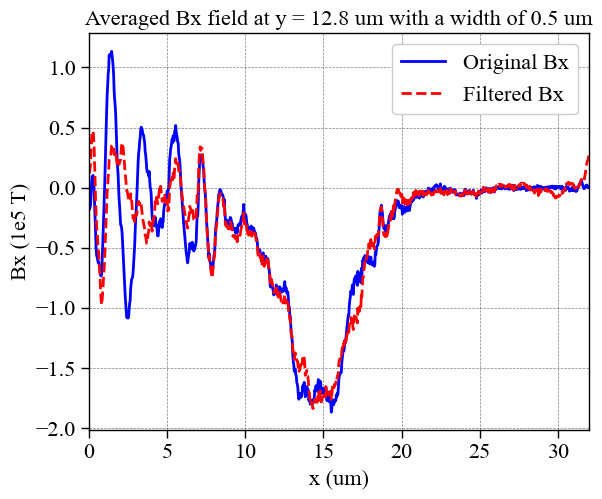

In [13]:
post_process_Bx_field(
    S1, k0x=0.4, k0y=0.4, wx=0.3, wy=0.4, timestep=9, vmin0=-2, vmax0=2
)

time =  166.60163705303134  fs
With these plots, you can identify the dominant spatial frequencies in the Bx field.
You can now design your mask to filter out unwanted frequencies accordingly.


/var/folders/2t/97rc3fl92tg15k2l_4sk5hsh0000gn/T/ipykernel_13683/464827179.py:124: RuntimeWarning: divide by zero encountered in log10
  np.log10(np.abs(data_fft_masked_shift).T),


6.406406406406406
max Bx_ori =  2.0906124826779733  GG
max Bx_filt =  1.8304341221331457  GG
error bar =  0.13008918027241378  GG
ave Bx =  1.9605233024055595  GG


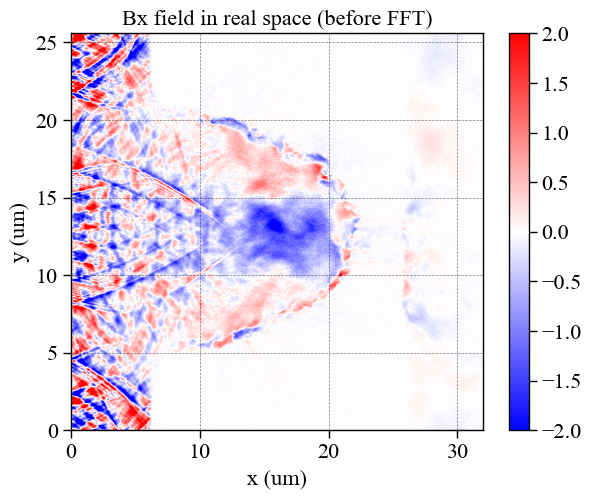

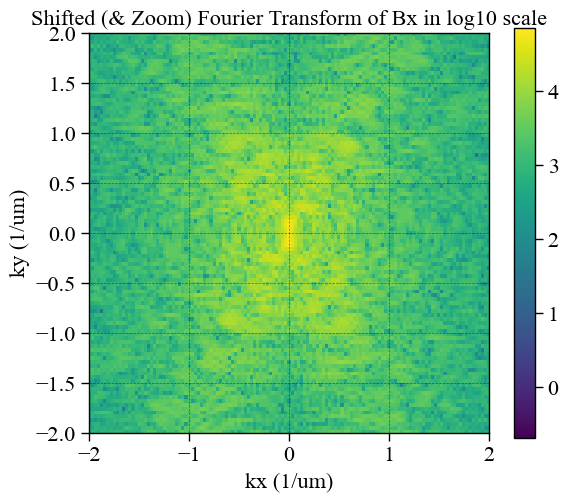

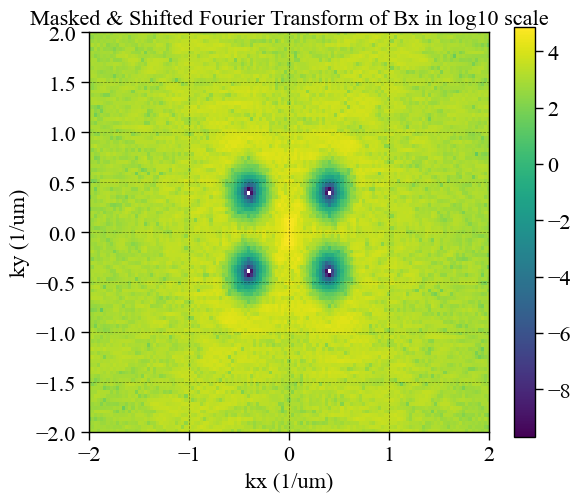

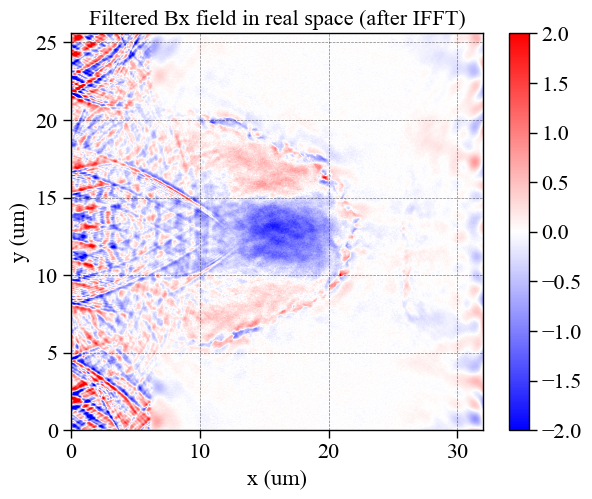

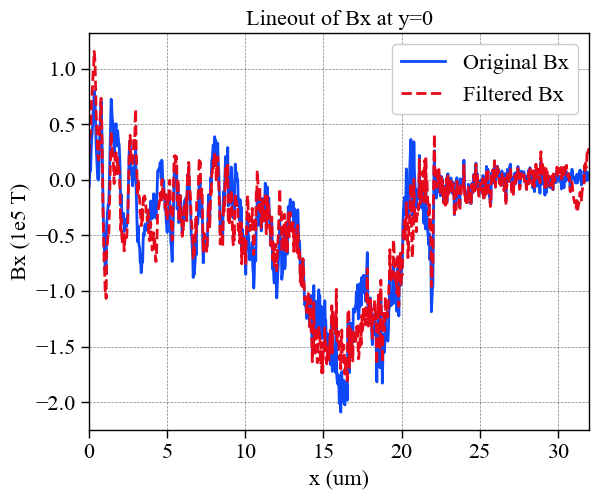

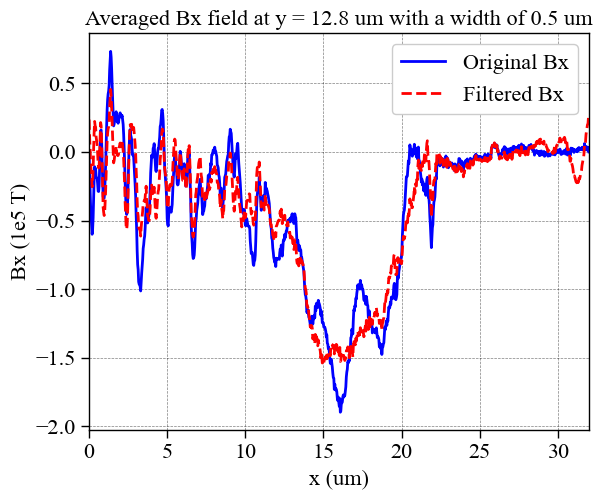

In [12]:
post_process_Bx_field(
    S2, k0x=0.4, k0y=0.4, wx=0.3, wy=0.4, timestep=10, vmin0=-2, vmax0=2
)